# Quantitative Robustness Evaluation

This notebook quantitatively assesses the topological stability of our primary $K=3$ VMPFC parcellation. To measure the spatial agreement between the baseline parcellation and the robustness check iterations (generated via different algorithms and activation thresholds), we compute the **Dice Similarity Coefficient (DSC)**.

Since cluster labels (e.g., 1, 2, 3) are arbitrarily assigned in unsupervised learning, we utilize a customized `max_dice_score` function to optimally align and match the functional subdivisions before calculating their spatial overlap. A Dice score closer to $1.0$ indicates perfect spatial agreement.

In [1]:
from utils.dice import max_dice_score

from pathlib import Path
import nibabel as nib
from tqdm import tqdm, trange
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale

plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = False
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')

# Path Settings
DATA_PATH = Path('../data')
PLOTS_PATH = Path('../plots')
RESULTS_PATH = Path('../results')

# Load Data
## Sensitivity to Data Inclusion Thresholds

First, we evaluate how the strictness of data inclusion (`MIN_STUDIES`) impacts the parcellation boundaries. We calculate the Dice overlap between the standard $K=3$ result (derived at `MIN_STUDIES = 150`) and the 100 iterative runs performed at thresholds of 100, 150, and 200 studies. High spatial overlap across these variations would indicate that our VMPFC subregions are not biased by the chosen activation threshold.

In [2]:
k = 3
KMeans_result_dict = dict()
for ms in [100, 150, 200]:
    data_1_raw = nib.load(RESULTS_PATH / f'nii/K{k}.nii.gz').get_fdata()
    result_data = []
    for random_state in trange(100, desc=f'ms={ms}'):
        data_file2 = RESULTS_PATH / f'robust/runs_ms{ms}/run_{random_state}_K{k}.nii.gz'
        if not data_file2.exists():
            continue
        data_2_raw = nib.load(data_file2).get_fdata()
        mask = (data_1_raw > 0) & (data_2_raw > 0)
        score = max_dice_score(data_1_raw[mask], data_2_raw[mask], k)
        result_data.append(score)
    KMeans_result_dict[ms] = result_data

for k, v in KMeans_result_dict.items():
    print(k, len(v))

ms=200: 100%|██████████| 100/100 [00:01<00:00, 78.22it/s]

100 100
150 100
200 100


## Stability Across Clustering Algorithms
### Agglomerative

Next, we compare the baseline K-Means topology against the 100 iterations generated by **Agglomerative Clustering** with spatial constraints. This step confirms whether the continuous spatial gradients of the VMPFC are interpreted consistently by hierarchical merging algorithms.

In [5]:
agglomerative_result_list = []
k = 3
data_1_raw = nib.load(RESULTS_PATH / f'nii/K{k}.nii.gz').get_fdata()
for random_state in trange(100, desc=f'k={k}'):
    data_file2 = RESULTS_PATH / f'robust/runs_Agglomerative/run_{random_state}_K{k}.nii.gz'
    data_2_raw = nib.load(data_file2).get_fdata()
    mask = (data_1_raw > 0) & (data_2_raw > 0)
    score = max_dice_score(data_1_raw[mask], data_2_raw[mask], k)
    agglomerative_result_list.append(score)
print(len(agglomerative_result_list))

k=3: 100%|██████████| 100/100 [00:01<00:00, 61.65it/s]

100


### Spectral

Similarly, we compute the spatial overlap between the baseline solution and the 100 iterations of **Spectral Clustering**. By checking against a graph-based method, we ensure our functional boundaries are not strictly dependent on the geometric assumptions inherent to K-Means.

In [7]:
spectral_result_list = []
k = 3
data_1_raw = nib.load(RESULTS_PATH / f'nii/K{k}.nii.gz').get_fdata()
for random_state in trange(100, desc=f'k={k}'):
    data_file2 = RESULTS_PATH / f'robust/runs_Spectral/run_{random_state}_K{k}.nii.gz'
    if not data_file2.exists():
        continue
    data_2_raw = nib.load(data_file2).get_fdata()
    mask = (data_1_raw > 0) & (data_2_raw > 0)
    score = max_dice_score(data_1_raw[mask], data_2_raw[mask], k)
    spectral_result_list.append(score)
print(len(spectral_result_list))

k=3: 100%|██████████| 100/100 [00:01<00:00, 71.70it/s]

100


# Visualizing Distribution of Spatial Agreement

To effectively summarize our robustness checks, we visualize the distribution of Dice scores using overlaid strip and box plots.

* **Left Panel:** Displays the spatial stability across different `MIN_STUDIES` thresholds (100, 150, 200), contextualized by the corresponding number of retained VMPFC voxels.
* **Right Panel:** Displays the spatial agreement between the standard K-Means algorithm and the alternative algorithms (Spectral and Agglomerative).

A red dashed line is set at $0.6$ as a conventional benchmark for "good" spatial overlap. Consistently high distributions well above this line will robustly validate our $K=3$ parcellation scheme.

In [ ]:
print(f'Kmeans ms=150: run {np.argmin(KMeans_result_dict[150])} has lowerest dice={min(KMeans_result_dict[150]):.3f}')
print(f'Kmeans ms=100: run {np.argmin(KMeans_result_dict[100])} has lowerest dice={min(KMeans_result_dict[100]):.3f}')
print(f'Kmeans ms=200: run {np.argmin(KMeans_result_dict[200])} has lowerest dice={min(KMeans_result_dict[200]):.3f}')
print(f'Spectral: run {np.argmin(spectral_result_list)} has lowerest dice={min(spectral_result_list):.3f}')
print(f'Agg: run {np.argmin(agglomerative_result_list)} has lowerest dice={min(agglomerative_result_list):.3f}')

In [8]:

def plot_distribution(plot_data, ax, x):
    # 2. 绘制散点图 (置于底层 zorder=1)
    # 散点使用中灰色，配合稍微大一点的透明度，这样大量点重叠时依然有层次
    sns.stripplot(
        y=plot_data,
        x=x,
        ax=ax,
        size=4.5,
        color=".4",
        alpha=0.25,
        jitter=0.25,
        zorder=1
    )

    sns.boxplot(
        x=x,
        y=plot_data,
        ax=ax,
        color=".15",
        boxprops={'facecolor': 'none'},  # 【关键】将箱体内部完全掏空，变成透明
        linecolor='black',
        width=0.2,
        linewidth=2,
        fliersize=0,
        zorder=2
    )


def set_ax(ax):
    ax.set_ylim(0.4, 1.05)
    ax.axhline(xmin=-0.5, xmax=3.5, y=0.6, color='crimson', linestyle='--', alpha=0.8, linewidth=1.5, zorder=0)
    ax.set_xticks(range(3))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

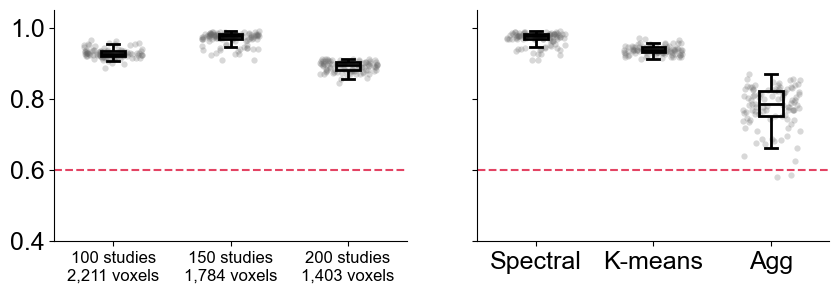

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes = axes.flatten()
ax = axes[1]
plot_distribution(KMeans_result_dict[150], ax, 1)
plot_distribution(spectral_result_list, ax, 0)
plot_distribution(agglomerative_result_list, ax, 2)
set_ax(ax)
ax.set_xticklabels(['Spectral', 'K-means', 'Agg', ], fontsize=18)

ax = axes[0]
plot_distribution(KMeans_result_dict[100], ax, 0)
plot_distribution(KMeans_result_dict[150], ax, 1)
plot_distribution(KMeans_result_dict[200], ax, 2)
set_ax(ax)
ax.set_xticklabels(['100 studies\n2,211 voxels', '150 studies\n1,784 voxels', '200 studies\n1,403 voxels'], fontsize=12)

ax.set_yticks([0.4, 0.6, 0.8, 1])
ax.set_yticklabels(['0.4', '0.6', '0.8', '1.0'], fontsize=18)

fig.savefig(PLOTS_PATH / 'robustness.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'robustness.svg', **PLOT_KWARGS_DICT)